# Data-Atmosphere

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
from datetime import datetime

import os
from io import StringIO
import requests

from windrose import WindroseAxes

## 1. Download data

### 1.1 Download all files 

Information about the selected station:  
https://www.ndbc.noaa.gov/station_page.php?station=42003 

Sample url:   
https://www.ndbc.noaa.gov/download_data.php?filename=42003h1990.txt.gz&dir=data/historical/stdmet/


In [2]:
download= False

if download:
    # Define the station ID (example: '42001' for Gulf of Mexico buoy)
    station_id = '42003'
    start_year = 1990
    current_year= 2022
    #current_year = datetime.now().year
    
    # Create directories for raw data
    raw_data_dir = f'input/station_{station_id}'
    os.makedirs(raw_data_dir, exist_ok=True)
    
    # Loop through each year and download the data
    for year in range(start_year, current_year + 1):
        url = f'https://www.ndbc.noaa.gov/view_text_file.php?filename={station_id}h{year}.txt.gz&dir=data/historical/stdmet/'
        print(f"Downloading data for year {year}...")    
        # Read the data
        #df = pd.read_csv(url, sep='\s+', header=[0], on_bad_lines='skip', low_memory=False)
        df = pd.read_csv(url, sep=r'\s+', header=[0], on_bad_lines='skip', low_memory=False)    
        # Save each individual file
        raw_file_path = os.path.join(raw_data_dir, f"wind_data_{year}.csv")
        df.to_csv(raw_file_path, index=False)
        display(df.head(2))
else:
    print('Skipping download and reading existing files from input/station_{ID}')

Skipping download and reading existing files from input/station_{ID}


### 1.2 File headers

The file headers are changing across years where names are revised or new columns are added.

In [3]:
# Define input and output paths
station_id = '42003'
input_dir =  f'input/station_{station_id}'
output_file = 'input/headers_summary.csv'

# Create a dataframe to store extracted headers
header_data = []

# Loop through each file in the input directory
for file in sorted(os.listdir(input_dir)):
    if file.endswith('.csv'):
        file_path = os.path.join(input_dir, file)
        
        try:
            # Read the file and extract the header rows
            with open(file_path, 'r') as f:
                header_lines = [next(f).strip() for _ in range(1)]  # First two rows
            
            # Store in the list
            header_data.append({
                'Year': file.split('_')[-1].split('.')[0],
                'Header_1': header_lines[0],
            })

            #print(f"Extracted headers for {file}:\n{header_lines}\n")

        except Exception as e:
            print(f"Failed to extract headers for {file}: {e}")

# Convert the list to a DataFrame
header_df = pd.DataFrame(header_data)

# Save the headers to a CSV file
header_df.to_csv(output_file, index=False)

print(f"\nHeaders saved to '{output_file}'")




Headers saved to 'input/headers_summary.csv'


### 1.3 Merge all files

In [4]:
# 1990-1999: 'YY',   'MM', 'DD', 'hh',       'WD',   'WSPD', 'GST', 'WVHT', 'DPD', 'APD','MWD', 'BAR',  'ATMP', 'WTMP', 'DEWP', 'VIS'
# 2000-2004: 'YYYY', 'MM', 'DD', 'hh',       'WD',   'WSPD', 'GST', 'WVHT', 'DPD', 'APD','MWD', 'BAR',  'ATMP', 'WTMP', 'DEWP', 'VIS', 'TIDE'
# 2005-2006: 'YYYY', 'MM', 'DD', 'hh', 'mm', 'WD',   'WSPD', 'GST', 'WVHT', 'DPD','APD', 'MWD', 'BAR',  'ATMP', 'WTMP', 'DEWP', 'VIS', 'TIDE'
# 2007-Now : 'YYYY', 'MM', 'DD', 'hh', 'mm', 'WDIR', 'WSPD', 'GST', 'WVHT', 'DPD','APD', 'MWD', 'PRES', 'ATMP', 'WTMP', 'DEWP', 'VIS', 'TIDE'
# 2007-Now: Contain commented header row

# Station and year settings
STATION_ID = '42003'
START_YEAR = 1990
END_YEAR = 2022
raw_data_dir = f'input/station_{STATION_ID}'

# Create an empty list to store processed data
all_data = []

# Loop through saved files
for year in range(START_YEAR, END_YEAR + 1):
    file_path = os.path.join(raw_data_dir, f"wind_data_{year}.csv")
    
    if not os.path.exists(file_path):
        print(f" File for year {year} not found, skipping...")
        continue
    
    try:
        #print(f"Processing data for year {year}...")

        # Read the file to capture the second row (units)
        if year == 2007:
            df = pd.read_csv(file_path, low_memory=False)
            display(df.head(2))
            
        # Read the file directly (use first row as header)
        df = pd.read_csv(file_path, skiprows=[1], low_memory=False)

        # Add missing 'minute' column if not present
        if 'mm' not in df.columns:
            df['mm'] = 0
        
        # Add missing 'TIDE' column if not present
        if 'TIDE' not in df.columns:
            df['TIDE'] = np.nan

        # Rename columns to match pd.to_datetime requirements
        df.rename(columns={
            'YY': 'year',
            '#YY': 'year',
            'YYYY': 'year',
            'MM': 'month',
            'DD': 'day',
            'hh': 'hour',
            'mm': 'minute',
            'WD': 'WDIR',   # Normalize wind direction column
            'BAR': 'PRES'   # Normalize pressure column
        }, inplace=True)
        
        # Convert 2-digit year to 4-digit format only if it's a two-digit year
        if 'year' in df.columns:
            df['year'] = df['year'].apply(lambda x: x + 1900 if x < 100 and x > 50 else (x + 2000 if x < 100 else x))

        # # Ensure that the 'year' column is numeric
        # if 'year' in df.columns:
        #     df['year'] = pd.to_numeric(df['year'], errors='coerce')  # Convert to numeric and set invalid entries to NaN
        #     df.dropna(subset=['year'], inplace=True)  # Drop invalid rows
        #     df['year'] = df['year'].astype(int)  # Convert back to integer

        # Create a single 'Timestamp' column (if time columns are available)
        if all(col in df.columns for col in ['year', 'month', 'day', 'hour', 'minute']):
            df['Timestamp'] = pd.to_datetime(
                df[['year', 'month', 'day', 'hour', 'minute']],
                errors='coerce'
            )
            #df.dropna(subset=['Timestamp'], inplace=True)
        else:
            print(f"Missing time columns for year {year}, skipping...")
            continue

        if (year == END_YEAR) | (year == START_YEAR):
            display(df.head(2))
        
        # Keep only necessary columns
        df.columns = df.columns.str.strip()
        cols_to_keep = ['Timestamp', 'WDIR', 'WSPD', 'ATMP', 'WTMP']
        existing_cols = [col for col in cols_to_keep if col in df.columns]
        df = df[existing_cols]

        # # Drop rows with missing values
        # df.dropna(inplace=True)

        # Set timestamp as the index
        df.set_index('Timestamp', inplace=True)

        # Append to combined data
        all_data.append(df)

        #print(f"Processed data for year {year}: {list(df.columns)}")

    except Exception as e:
        print(f" Failed to process data for year {year}: {e}")
        continue

# Combine all processed data
if all_data:
    final_data = pd.concat(all_data)
    final_data.sort_index(inplace=True)

    # Replace placeholder values with NaN
    print('Replacing placeholder values including 999 and 99 with NaN')
    final_data.replace([999, 999.0, 99, 99.0], np.nan, inplace=True)

    # Save to CSV
    output_file = 'output/wind_data_cleaned.csv'
    final_data.to_csv(output_file)
    print(f"\n Final combined data saved to '{output_file}'")

    # Display the final processed data preview
    print("\n Final data preview:")
    display(final_data)

    display(final_data.describe().loc[['min', 'mean', 'max'],:])

else:
    print("\n No valid data to combine!")



,year,month,day,hour,WDIR,WSPD,GST,WVHT,DPD,APD,MWD,PRES,ATMP,WTMP,DEWP,VIS,minute,TIDE,Timestamp
0,1990,1,1,1,211,6.4,7.5,1.5,7.1,5.6,999,1017.3,25.3,26.1,999.0,99.0,0,NaN,1990-01-01 01:00:00
1,1990,1,1,2,220,5.5,6.5,1.7,6.7,5.8,999,1017.9,25.3,26.1,999.0,99.0,0,NaN,1990-01-01 02:00:00


,#YY,MM,DD,hh,mm,WDIR,WSPD,GST,WVHT,DPD,APD,MWD,PRES,ATMP,WTMP,DEWP,VIS,TIDE
0,#yr,mo,dy,hr,mn,degT,m/s,m/s,m,sec,sec,degT,hPa,degC,degC,degC,nmi,ft
1,2007,01,01,00,00,185,5.7,6.9,1.56,6.67,5.45,143,1017.6,26.5,26.9,24.5,99.0,99.00


,year,month,day,hour,minute,WDIR,WSPD,GST,WVHT,DPD,APD,MWD,PRES,ATMP,WTMP,DEWP,VIS,TIDE,Timestamp
0,2022,8,6,21,30,108,6.3,8.2,99.00,99.00,99.00,999,1016.1,999.0,30.1,999.0,99.0,99.0,2022-08-06 21:30:00
1,2022,8,6,21,40,103,6.4,9.0,1.01,5.56,4.67,119,1016.4,29.4,30.0,25.2,99.0,99.0,2022-08-06 21:40:00


Replacing placeholder values including 999 and 99 with NaN

 Final combined data saved to 'output/wind_data_cleaned.csv'

 Final data preview:


,WDIR,WSPD,ATMP,WTMP
Timestamp,,,,
1990-01-01 01:00:00,211.0,6.4,25.3,26.1
1990-01-01 02:00:00,220.0,5.5,25.3,26.1
1990-01-01 03:00:00,201.0,6.0,25.3,26.1
1990-01-01 04:00:00,202.0,6.3,25.2,26.1
1990-01-01 05:00:00,199.0,6.4,25.1,26.1
...,...,...,...,...
2022-09-21 13:30:00,29.0,4.2,28.4,29.4
2022-09-21 13:40:00,37.0,4.3,28.5,29.4
2022-09-21 13:50:00,53.0,3.7,28.5,29.4


,WDIR,WSPD,ATMP,WTMP
min,0.000000,0.000000,11.200000,20.00000
mean,136.314668,5.734006,25.467262,27.34473
max,360.000000,28.600000,34.300000,34.50000


## 2. Plot data

### 2.1 Wind speed over time and wind rose

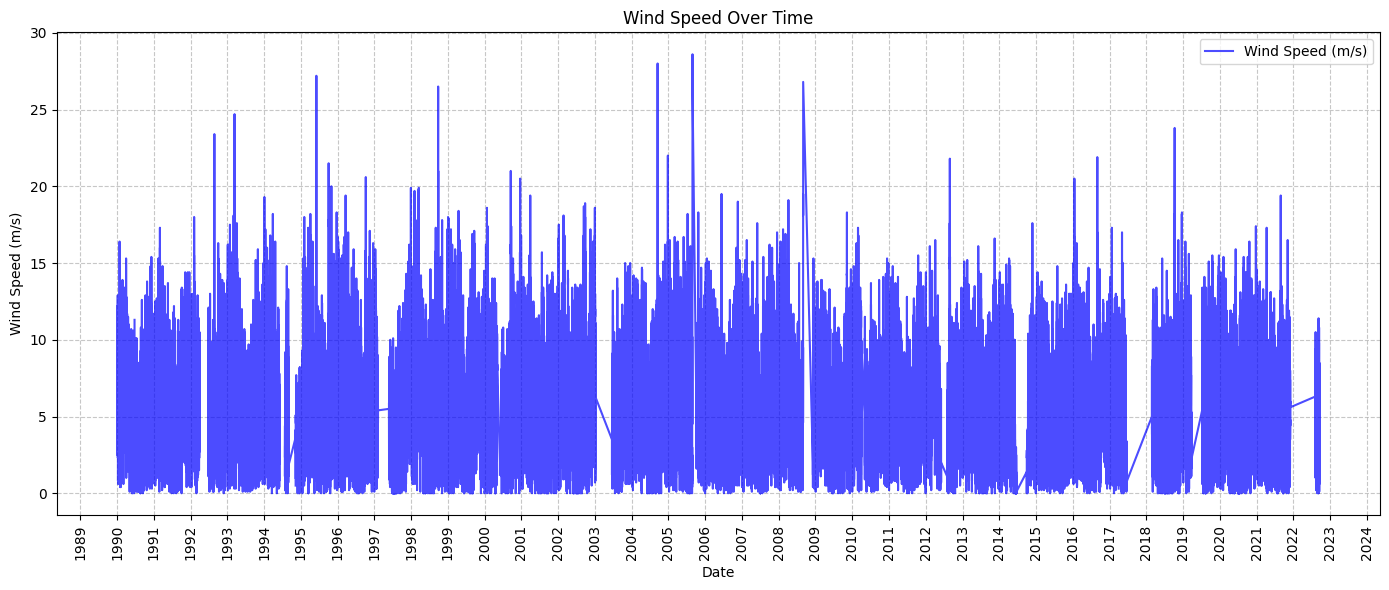

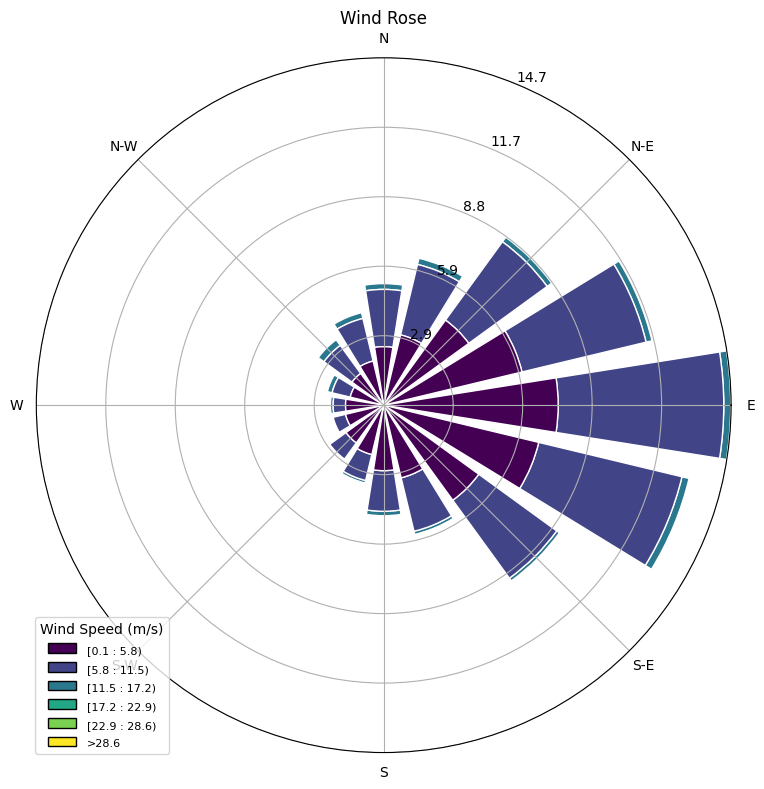

In [5]:
#  Create 'figures' folder if it doesn't exist
if not os.path.exists('figures'):
    os.makedirs('figures')


#  Load the cleaned data
file_path = 'output/wind_data_cleaned.csv'
data = pd.read_csv(file_path, parse_dates=['Timestamp'], index_col='Timestamp')


# Ask user for start and end years
start_year = 1990
end_year = 2022

# Filter data by user-selected years
data = data[(data.index.year >= start_year) & (data.index.year <= end_year)]



#  Wind Speed Over Time
def plot_wind_speed_over_time(data):
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(data.index, data['WSPD'], color='blue', label='Wind Speed (m/s)', alpha=0.7)
    ax.set_title('Wind Speed Over Time')
    ax.set_xlabel('Date')
    ax.set_ylabel('Wind Speed (m/s)')

    #ax.xaxis.set_major_formatter(DateFormatter('%Y-%m'))  # Format x-axis labels
    # Set major ticks for each year
    ax.xaxis.set_major_locator(mdates.YearLocator(1))  # Every year
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format as year
    
    plt.xticks(rotation=90)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    plt.tight_layout()

    #  Save and show
    plt.savefig('figures/wind_speed_over_time.png', dpi=300)
    plt.show()

#  Wind Rose Plot
def plot_wind_rose(data):
    # Remove NaN and unrealistic values for plotting
    df = data[['WDIR', 'WSPD']].dropna()
    df = df[df['WSPD'] > 0]  # Keep positive wind speeds only

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='windrose')

    # Plot the wind rose
    ax.bar(
        df['WDIR'], 
        df['WSPD'], 
        normed=True, 
        opening=0.8, 
        edgecolor='white'
    )

    ax.set_title('Wind Rose')
    ax.set_legend(title="Wind Speed (m/s)")
    plt.tight_layout()

    #  Save and show
    plt.savefig('figures/wind_rose.png', dpi=300)
    plt.show()

#  Run the plotting functions
plot_wind_speed_over_time(data)
plot_wind_rose(data)


## 2.2 Seasonal patterns 

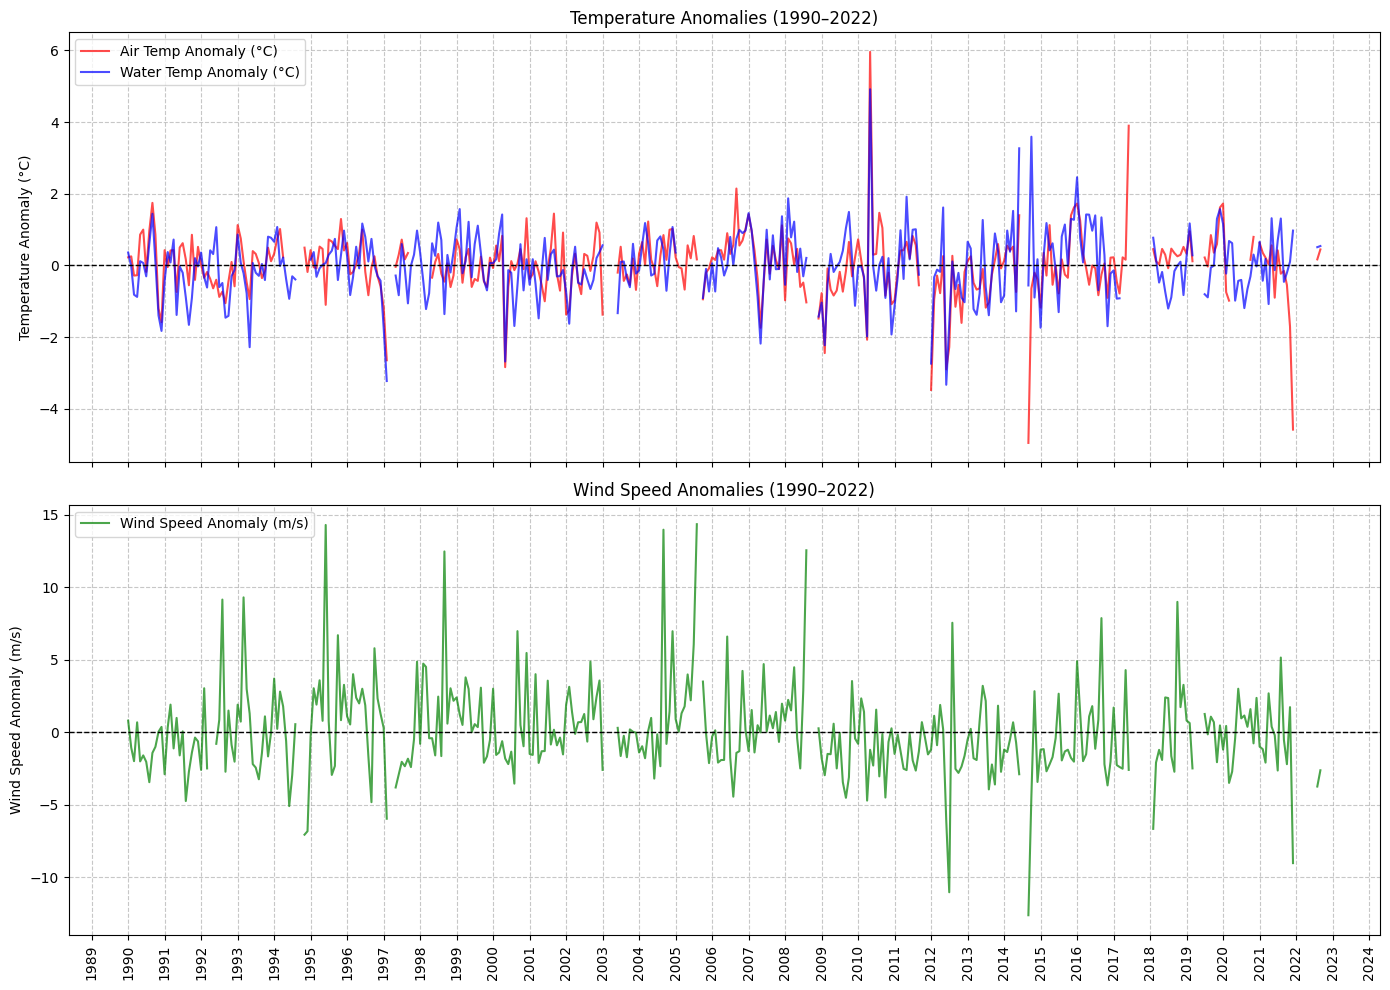


Anomaly plot saved to: figures/temperature_wind_anomalies_1990_2022.png


In [12]:
#  Create 'figures' folder if it doesn't exist
if not os.path.exists('figures'):
    os.makedirs('figures')

#  Load the cleaned data
file_path = 'output/wind_data_cleaned.csv'
data = pd.read_csv(file_path, parse_dates=['Timestamp'], index_col='Timestamp')

#  Ask user for start and end years
start_year = 1990
end_year = 2022

#  Filter data by user-selected years
data = data[(data.index.year >= start_year) & (data.index.year <= end_year)]
data = data.resample('MS').max()

#  1. Compute Baseline Seasonal Mean
def compute_baseline(data):
    # Extract month for grouping
    data['Month'] = data.index.month
    
    # Compute monthly baseline mean over all years
    baseline = data.groupby('Month')[['ATMP', 'WTMP', 'WSPD']].mean()
    
    return baseline

#  2. Compute Anomalies
def compute_anomalies(data, baseline):
    # Merge baseline into the original data based on the month
    data['ATMP_Baseline'] = data['Month'].map(baseline['ATMP'])
    data['WTMP_Baseline'] = data['Month'].map(baseline['WTMP'])
    data['WSPD_Baseline'] = data['Month'].map(baseline['WSPD'])

    # Compute anomalies as deviations from baseline
    data['ATMP_Anomaly'] = data['ATMP'] - data['ATMP_Baseline']
    data['WTMP_Anomaly'] = data['WTMP'] - data['WTMP_Baseline']
    data['WSPD_Anomaly'] = data['WSPD'] - data['WSPD_Baseline']
    
    return data

#  3. Plot Temperature and Wind Speed Anomalies (Subplots)
def plot_temperature_and_wind_anomalies(data):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    #  Plot Air and Water Temperature Anomalies (First Subplot)
    ax1.plot(data.index, data['ATMP_Anomaly'], label='Air Temp Anomaly (°C)', color='red', alpha=0.7)
    ax1.plot(data.index, data['WTMP_Anomaly'], label='Water Temp Anomaly (°C)', color='blue', alpha=0.7)
    
    ax1.axhline(0, color='black', linestyle='--', linewidth=1)  # Baseline reference line
    ax1.set_ylabel('Temperature Anomaly (°C)')
    ax1.set_title(f'Temperature Anomalies ({start_year}–{end_year})')
    ax1.legend(loc='upper left')
    ax1.grid(True, linestyle='--', alpha=0.7)

    #  Plot Wind Speed Anomalies (Second Subplot)
    ax2.plot(data.index, data['WSPD_Anomaly'], label='Wind Speed Anomaly (m/s)', color='green', alpha=0.7)
    
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)  # Baseline reference line
    ax2.set_ylabel('Wind Speed Anomaly (m/s)')
    ax2.set_title(f'Wind Speed Anomalies ({start_year}–{end_year})')
    ax2.legend(loc='upper left')
    ax2.grid(True, linestyle='--', alpha=0.7)

    #  Set major ticks for each year on the x-axis (shared)
    ax2.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator(1))
    ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

    plt.xticks(rotation=90)

    plt.tight_layout()

    #  Save and show plot
    output_path = f'figures/temperature_wind_anomalies_{start_year}_{end_year}.png'
    plt.savefig(output_path, dpi=300)
    plt.show()

    print(f"\nAnomaly plot saved to: {output_path}")

#  Run the functions
if not data.empty:
    baseline = compute_baseline(data)
    data = compute_anomalies(data, baseline)
    plot_temperature_and_wind_anomalies(data)
else:
    print(f"No data available between {start_year} and {end_year}.")


99th percentile wind speed threshold: 13.10 m/s


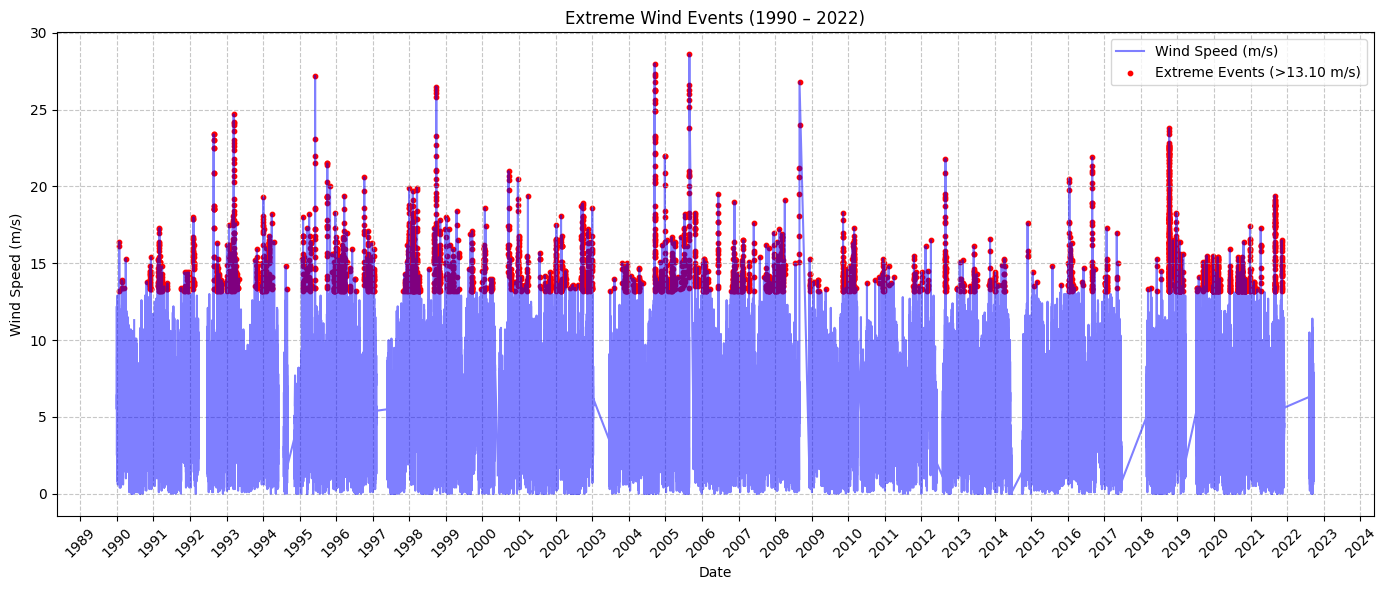


 Extreme event plot saved to: figures/extreme_events_1990_2022.png


In [8]:
#  Create 'figures' folder if it doesn't exist
if not os.path.exists('figures'):
    os.makedirs('figures')

#  Load the cleaned data
file_path = 'output/wind_data_cleaned.csv'
data = pd.read_csv(file_path, parse_dates=['Timestamp'], index_col='Timestamp')

#  User input for time range
start_year = 1990
end_year = 2022

#  Filter data for the selected range
data = data[(data.index.year >= start_year) & (data.index.year <= end_year)]

#  Compute 9xth percentile for extreme events
value=0.99
threshold = data['WSPD'].quantile(value)
print(f"{value*100:.0f}th percentile wind speed threshold: {threshold:.2f} m/s")

#  Identify extreme events
extreme_events = data[data['WSPD'] > threshold]

#  Load storm data (Optional) – Example format should be a CSV with ['Timestamp', 'Event'] 
# Ensure storm data is consistent with wind data time format
storm_data_path = 'input/storm_data.csv'
if os.path.exists(storm_data_path):
    storms = pd.read_csv(storm_data_path, parse_dates=['Timestamp'])
    storms = storms[(storms['Timestamp'] >= data.index.min()) & (storms['Timestamp'] <= data.index.max())]
else:
    storms = None

#  Plot extreme wind events
fig, ax = plt.subplots(figsize=(14, 6))

# Plot all wind speeds
ax.plot(data.index, data['WSPD'], color='blue', alpha=0.5, label='Wind Speed (m/s)')

# Highlight extreme events
ax.scatter(
    extreme_events.index, 
    extreme_events['WSPD'], 
    color='red', 
    s=10, 
    label=f'Extreme Events (>{threshold:.2f} m/s)'
)

# Overlay storm events if available
if storms is not None:
    for _, row in storms.iterrows():
        ax.axvline(row['Timestamp'], color='black', linestyle='--', alpha=0.7, label=row['Event'])

#  Format x-axis
ax.xaxis.set_major_locator(mdates.YearLocator(1))  # Every year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format as year
plt.xticks(rotation=45)

#  Labels and title
ax.set_title(f'Extreme Wind Events ({start_year} – {end_year})')
ax.set_xlabel('Date')
ax.set_ylabel('Wind Speed (m/s)')

#  Add legend
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(unique_labels.values(), unique_labels.keys(), loc='upper right')

#  Grid and layout
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

#  Save and show plot
output_path = f'figures/extreme_events_{start_year}_{end_year}.png'
plt.savefig(output_path, dpi=300)
plt.show()

print(f"\n Extreme event plot saved to: {output_path}")

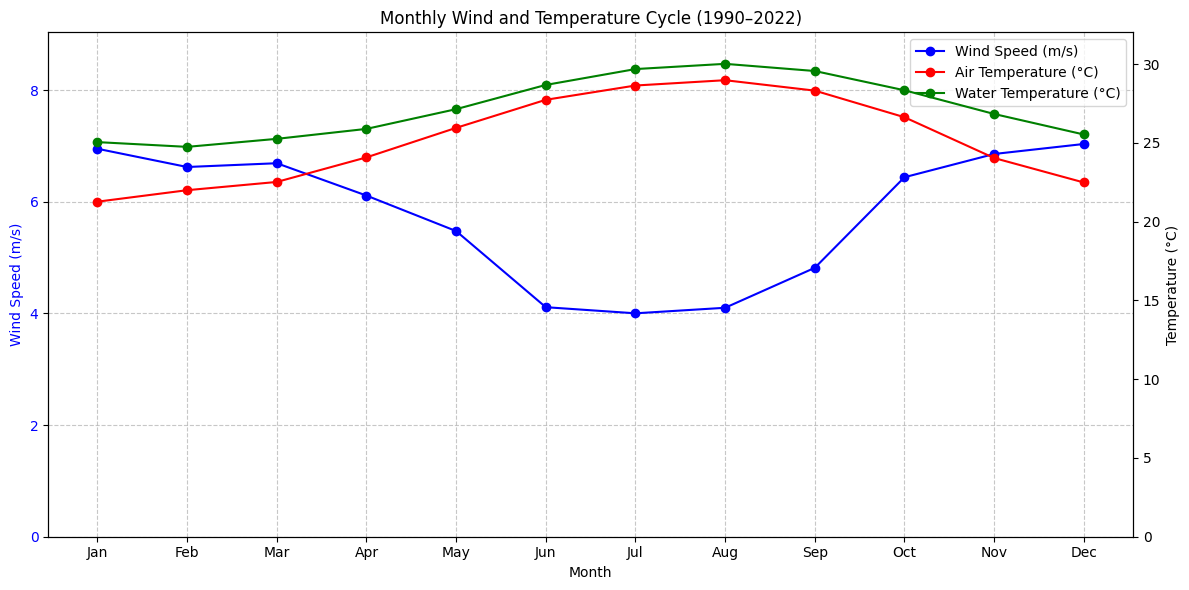


 Monthly cycle plot saved to: figures/monthly_cycle_1990_2022.png


In [10]:
#  Create 'figures' folder if it doesn't exist
if not os.path.exists('figures'):
    os.makedirs('figures')

#  Load the cleaned data
file_path = 'output/wind_data_cleaned.csv'
data = pd.read_csv(file_path, parse_dates=['Timestamp'], index_col='Timestamp')

#  User input for time range
start_year = 1990
end_year = 2022

#  Filter data for the selected range
data = data[(data.index.year >= start_year) & (data.index.year <= end_year)]

#  Group by month and calculate mean values
monthly_cycle = data.groupby(data.index.month)[['WSPD', 'ATMP', 'WTMP']].mean()

#  Plot monthly wind and temperature cycle
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot wind speed
ax1.plot(
    monthly_cycle.index, 
    monthly_cycle['WSPD'], 
    label='Wind Speed (m/s)', 
    color='blue', 
    marker='o'
)

# Format left y-axis for wind speed
ax1.set_ylabel('Wind Speed (m/s)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim(0, monthly_cycle['WSPD'].max() + 2)

#  Create a second y-axis for temperature
ax2 = ax1.twinx()

# Plot air temperature
ax2.plot(
    monthly_cycle.index, 
    monthly_cycle['ATMP'], 
    label='Air Temperature (°C)', 
    color='red', 
    marker='o'
)

# Plot water temperature
ax2.plot(
    monthly_cycle.index, 
    monthly_cycle['WTMP'], 
    label='Water Temperature (°C)', 
    color='green', 
    marker='o'
)

# Format right y-axis for temperature
ax2.set_ylabel('Temperature (°C)', color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(0, monthly_cycle[['ATMP', 'WTMP']].max().max() + 2)

#  Add labels and legend
ax1.set_title(f'Monthly Wind and Temperature Cycle ({start_year}–{end_year})')
ax1.set_xlabel('Month')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
])

#  Add combined legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

#  Grid and layout
ax1.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

#  Save and show plot
output_path = f'figures/monthly_cycle_{start_year}_{end_year}.png'
plt.savefig(output_path, dpi=300)
plt.show()

print(f"\n Monthly cycle plot saved to: {output_path}")
